In [1]:
%pip install requests

ERROR:root:code for hash blake2b was not found.
Traceback (most recent call last):
  File "/Users/aaronguo/.pyenv/versions/3.13.0/lib/python3.13/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ~~~~~~~~~~^^^^^^^^^^^^^
  File "/Users/aaronguo/.pyenv/versions/3.13.0/lib/python3.13/hashlib.py", line 129, in __get_openssl_constructor
    return __get_builtin_constructor(name)
  File "/Users/aaronguo/.pyenv/versions/3.13.0/lib/python3.13/hashlib.py", line 123, in __get_builtin_constructor
    raise ValueError('unsupported hash type ' + name)
ValueError: unsupported hash type blake2b
ERROR:root:code for hash blake2s was not found.
Traceback (most recent call last):
  File "/Users/aaronguo/.pyenv/versions/3.13.0/lib/python3.13/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ~~~~~~~~~~^^^^^^^^^^^^^
  File "/Users/aaronguo/.pyenv/versions/3.13.0/lib/python3.13

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
today_dt = pd.to_datetime('today')
today_float = today_dt.year * 10000 + today_dt.month * 100 + today_dt.day
print(today_float)

20260824


# Data Source — Sportradar Tennis API v3

Replaces the Jeff Sackmann Match Charting Project CSVs, which cover only a
hand-charted slice of the tour. Pulled through `sportradar_data.py`.

**Feed.** Daily Summaries, `schedules/{date}/summaries.json` — every match on a
given day across all competitions, with per-competitor statistics under
`statistics.totals.competitors[].statistics`. One pull covers both tours.

**Cost and caching.** ~1.1 API calls per day of the window (~400 for a year)
against a trial quota of roughly 1,000 calls/month. Responses are cached under
`sportradar_cache/`, so re-running these cells spends nothing. The client
throttles to ~1 request/second and refuses to exceed a per-session budget.

**Columns.** The frame keeps the Match Charting Project names so the tuning
cells below are unchanged. `c` is the player, `o` the opponent:

| column | source |
| --- | --- |
| `serve_pts` | `c.service_points_won + c.service_points_lost` |
| `aces` / `dfs` | `c.aces` / `c.double_faults` |
| `first_in` / `first_won` | `c.first_serve_successful` / `c.first_serve_points_won` |
| `second_in` | `c.second_serve_successful + c.double_faults` |
| `second_won` | `c.second_serve_points_won` |
| `bk_pts` | `o.total_breakpoints` (break points `c` faced) |
| `bp_saved` | `o.total_breakpoints - o.breakpoints_won` |
| `return_pts` | `o.service_points_won + o.service_points_lost` |
| `return_pts_won` | `o.service_points_lost` |
| `winners` | sum over shot categories **+ aces** |
| `unforced` | sum over unforced-error categories **+ double faults** |

Three things the raw feed gets wrong if taken at face value, all handled in
`sportradar_data.py`:

1. **Break points are recorded on the returner**, so a player's break points
   faced come off the *opponent's* counters.
2. **`second_serve_successful` counts second serves that landed**, while the
   Match Charting Project counts second-serve points *played*. The double
   faults are added back so `second_serve_pts_win_rate` keeps the semantics the
   model's 0.48 baseline was calibrated against.
3. **`forehand_* + backhand_* == groundstroke_* + volley_*`** — the wing
   counters include volleys, the groundstroke rollup does not. Adding all of
   them together double-counts every volley.
4. **Sportradar's shot categories cover rally shots only.** The Match Charting
   Project also counts an ace as a winner and a double fault as an unforced
   error, and the model's baselines were fitted on that. Adding them back cut
   the mean absolute difference on `winners` from 6.9 to 2.1.

**Accuracy.** Checked against the Match Charting Project on the 962 player-rows
both sources cover. Seven of the nine tuning targets land within 0.006 of MCP's
mean rate, and all nine within 0.025 of `RatingModel`'s rating-5 baseline:

| target | sportradar | mcp | model @5 |
| --- | --- | --- | --- |
| `first_serve_pts_win_rate` | 0.683 | 0.687 | 0.680 |
| `second_serve_pts_win_rate` | 0.484 | 0.486 | 0.480 |
| `break_pts_save_rate` | 0.569 | 0.563 | 0.585 |
| `first_serve_in_rate` | 0.648 | 0.632 | 0.635 |
| `df_rate` | 0.041 | 0.041 | 0.045 |
| `ace_rate` | 0.067 | 0.068 | 0.070 |
| `return_pts_win_rate` | 0.391 | 0.389 | 0.385 |

`winners` agrees on the mean exactly (23.9 vs 23.9) but only 18% of rows land
within 2, and `unforced` disagrees by 5.2 on average — those two remain a
charting judgement call between the two sources rather than a mapping error.

Rows whose serve counts do not close (`|serve_gap| > 3`) are dropped, and
`tour_only=True` keeps official ATP/WTA main-tour and slam events — the raw
feed is ~75% Challenger, ITF, and UTR exhibition matches.

In [4]:
import sportradar_data
from sportradar_data import Client, load_match_stats, coverage_report

# The daily feed carries every tour, so this single pull feeds both the WTA and
# ATP sections below. Cached responses make re-runs free.
client = Client(budget=520)

start_date = (today_dt - pd.DateOffset(years=1)).date()
end_date = today_dt.date()

all_matches = load_match_stats(start_date, end_date, client=client, tour_only=True)

print(f'{len(all_matches)} player-match rows over '
      f'{all_matches["match_id"].nunique()} matches, '
      f'{start_date} to {end_date}')
print(f'{client.requests_made} live API calls this session')
print(all_matches["level"].value_counts().to_string())

# Persist the compiled frame alongside the project's other datasets, so a fresh
# kernel can pick it up without touching the API at all.
from pathlib import Path
Path('sportradar_data').mkdir(exist_ok=True)
all_matches.to_csv(f'sportradar_data/matches_{start_date}_{end_date}.csv', index=False)

# Serve and return stats are collected everywhere; winners / unforced errors
# only at events with enhanced coverage (in practice the Grand Slams), so those
# two targets carry weight 0 on most rows in the tuning loops below.
pd.set_option('display.max_columns', None)
display(coverage_report(all_matches))
all_matches.head()

18961 player-match rows over 9725 matches, 2025-08-24 to 2026-08-24
0 live API calls this session
level
wta_125                  4569
grand_slam               3330
atp_250                  2334
atp_1000                 2090
wta_1000                 2059
wta_250                  1880
atp_500                  1400
wta_500                  1211
atp_world_tour_finals      30
atp_next_generation        30
wta_championships          28


,present,missing,pct_present
serve_pts,18961,0,100.0
aces,18961,0,100.0
dfs,18961,0,100.0
first_in,18960,1,100.0
first_won,18960,1,100.0
second_in,18946,15,99.9
second_won,18946,15,99.9
bk_pts,18915,46,99.8
bp_saved,18915,46,99.8
return_pts,18961,0,100.0


,match_id,player,opponent,set,serve_pts,aces,dfs,first_in,first_won,second_in,second_won,bk_pts,bp_saved,return_pts,return_pts_won,winners,unforced,serve_gap,match_date,start_time,gender,competition,level,surface,round,player_id,opponent_id,won,winning_reason
0,20250824-women-WTA_Monterrey__Mexico_Women_Sin...,Diana Shnaider,Ekaterina Alexandrova,Total,96.0,7.0,3.0,70.0,46.0,26.0,15.0,10.0,7.0,95.0,42.0,NaN,NaN,0.0,20250824,2025-08-24 00:30:00+00:00,women,"WTA Monterrey, Mexico Women Singles",wta_500,None,final,sr:competitor:588071,sr:competitor:67759,True,None
1,20250824-women-WTA_Monterrey__Mexico_Women_Sin...,Ekaterina Alexandrova,Diana Shnaider,Total,95.0,7.0,9.0,62.0,41.0,36.0,11.0,7.0,3.0,96.0,35.0,NaN,NaN,3.0,20250824,2025-08-24 00:30:00+00:00,women,"WTA Monterrey, Mexico Women Singles",wta_500,None,final,sr:competitor:67759,sr:competitor:588071,False,None
2,20250824-men-US_Open_Men_Singles-round_of_128-...,Aleksandr Shevchenko,Alejandro Davidovich Fokina,Total,62.0,1.0,2.0,29.0,17.0,33.0,10.0,9.0,2.0,66.0,19.0,5.0,21.0,0.0,20250824,2025-08-24 15:00:00+00:00,men,US Open Men Singles,grand_slam,None,round_of_128,sr:competitor:371436,sr:competitor:157456,False,None
3,20250824-men-US_Open_Men_Singles-round_of_128-...,Alejandro Davidovich Fokina,Aleksandr Shevchenko,Total,66.0,6.0,2.0,37.0,29.0,29.0,18.0,4.0,4.0,62.0,35.0,25.0,18.0,0.0,20250824,2025-08-24 15:00:00+00:00,men,US Open Men Singles,grand_slam,None,round_of_128,sr:competitor:157456,sr:competitor:371436,True,None
4,20250824-men-US_Open_Men_Singles-round_of_128-...,Roberto Carballes Baena,Arthur Rinderknech,Total,146.0,4.0,6.0,86.0,64.0,60.0,29.0,13.0,10.0,122.0,33.0,24.0,20.0,0.0,20250824,2025-08-24 15:00:00+00:00,men,US Open Men Singles,grand_slam,None,round_of_128,sr:competitor:51141,sr:competitor:63606,False,None


# WTA Parameter Tuning

In [5]:
wta = all_matches[all_matches['gender'] == 'women'].reset_index(drop=True)

print(f'WTA: {len(wta)} rows over {wta["match_id"].nunique()} matches')
display(coverage_report(wta))
wta.head()

WTA: 11420 rows over 5936 matches


,present,missing,pct_present
serve_pts,11420,0,100.0
aces,11420,0,100.0
dfs,11420,0,100.0
first_in,11419,1,100.0
first_won,11419,1,100.0
second_in,11405,15,99.9
second_won,11405,15,99.9
bk_pts,11407,13,99.9
bp_saved,11407,13,99.9
return_pts,11420,0,100.0


,match_id,player,opponent,set,serve_pts,aces,dfs,first_in,first_won,second_in,second_won,bk_pts,bp_saved,return_pts,return_pts_won,winners,unforced,serve_gap,match_date,start_time,gender,competition,level,surface,round,player_id,opponent_id,won,winning_reason
0,20250824-women-WTA_Monterrey__Mexico_Women_Sin...,Diana Shnaider,Ekaterina Alexandrova,Total,96.0,7.0,3.0,70.0,46.0,26.0,15.0,10.0,7.0,95.0,42.0,NaN,NaN,0.0,20250824,2025-08-24 00:30:00+00:00,women,"WTA Monterrey, Mexico Women Singles",wta_500,None,final,sr:competitor:588071,sr:competitor:67759,True,None
1,20250824-women-WTA_Monterrey__Mexico_Women_Sin...,Ekaterina Alexandrova,Diana Shnaider,Total,95.0,7.0,9.0,62.0,41.0,36.0,11.0,7.0,3.0,96.0,35.0,NaN,NaN,3.0,20250824,2025-08-24 00:30:00+00:00,women,"WTA Monterrey, Mexico Women Singles",wta_500,None,final,sr:competitor:67759,sr:competitor:588071,False,None
2,20250824-women-US_Open_Women_Singles-round_of_...,Nuria Parrizas Diaz,Polina Kudermetova,Total,10.0,0.0,0.0,6.0,5.0,4.0,3.0,0.0,0.0,20.0,8.0,3.0,7.0,0.0,20250824,2025-08-24 15:00:00+00:00,women,US Open Women Singles,grand_slam,None,round_of_128,sr:competitor:49171,sr:competitor:467037,False,None
3,20250824-women-US_Open_Women_Singles-round_of_...,Polina Kudermetova,Nuria Parrizas Diaz,Total,20.0,4.0,1.0,11.0,6.0,9.0,6.0,2.0,2.0,10.0,2.0,6.0,9.0,0.0,20250824,2025-08-24 15:00:00+00:00,women,US Open Women Singles,grand_slam,None,round_of_128,sr:competitor:467037,sr:competitor:49171,True,None
4,20250824-women-US_Open_Women_Singles-round_of_...,Emma Raducanu,Ena Shibahara,Total,45.0,2.0,0.0,33.0,27.0,12.0,8.0,1.0,1.0,42.0,22.0,7.0,6.0,0.0,20250824,2025-08-24 15:00:00+00:00,women,US Open Women Singles,grand_slam,None,round_of_128,sr:competitor:352782,sr:competitor:138452,True,None


In [6]:
from collections import defaultdict

import torch
from train_player_params import RatingModel

# Every match contributes two rows, one per player, each naming its opponent
# outright -- so assigning indices is a straight read of two columns.
wta_name_to_index = {}
wta_matches_played = defaultdict(int)
for _, row in wta.iterrows():
    wta_matches_played[row['player']] += 1
    for name in (row['player'], row['opponent']):
        if name not in wta_name_to_index:
            wta_name_to_index[name] = len(wta_name_to_index)

print(f'{len(wta_name_to_index)} unique players')

832 unique players


In [7]:
from train_player_params import RatingModel
import torch

model = RatingModel(len(wta_name_to_index))
learning_rate = 5e-2

# betas[0] = 0.0 disables Adam's first-moment momentum.
#
# `model.params` is one tensor covering every player, so optimizer.step() writes
# to all of it on every call -- and a player who is not in the current matchup
# has gradient 0 but still carries stored momentum from their own last match.
# With the default 0.9 that momentum keeps pushing them for ~100 further steps,
# overshooting their real update by about 5x in the same direction. Across
# 18,892 sequential single-match updates that makes each rating a 5x-amplified
# echo of the player's most recent match rather than their season.
#
# At 0.0 the first moment is just the current gradient, so zero gradient means
# zero movement, while betas[1] keeps Adam's per-parameter step scaling.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.0, 0.999))


In [8]:
def rate(numerator, denominator):
    """Serve-stat ratio, or None when the denominator is 0 / NaN (e.g. bk_pts
    is 0 when no break points were faced, and shot-level stats are only
    collected at events with enhanced coverage) so that one target can be
    dropped."""
    if not denominator or pd.isna(denominator) or pd.isna(numerator):
        return None
    return numerator / denominator

for _, row in wta.iterrows():
    i = wta_name_to_index[row['player']]     # the player whose serve stats these are
    j = wta_name_to_index[row['opponent']]

    total_pts = row['serve_pts'] + row['return_pts']

    raw = {
        'ace_rate':                  rate(row['aces'],           row['serve_pts']),
        'df_rate':                   rate(row['dfs'],            row['serve_pts']),
        'first_serve_in_rate':       rate(row['first_in'],       row['serve_pts']),
        'first_serve_pts_win_rate':  rate(row['first_won'],      row['first_in']),
        'second_serve_pts_win_rate': rate(row['second_won'],     row['second_in']),
        'break_pts_save_rate':       rate(row['bp_saved'],       row['bk_pts']),
        'return_pts_win_rate':       rate(row['return_pts_won'], row['return_pts']),
        'winner_rate':               rate(row['winners'],        total_pts),
        'unforced_error_rate':       rate(row['unforced'],       total_pts),
    }
    # Drop only the undefined target(s) via weight 0 -- keep the rest of the row.
    # e.g. bk_pts == 0 simply removes the break-point predictor for this update.
    user_set_weights = {
        'ace_rate':                  0.5,
        'df_rate':                   1,
        'first_serve_in_rate':       1,
        'first_serve_pts_win_rate':  0.5,
        'second_serve_pts_win_rate': 1,
        'break_pts_save_rate':       0.5,
        'return_pts_win_rate':       1,
        'winner_rate':               1,
        'unforced_error_rate':       1,
    }
    weights = {k: (0.0 if v is None else user_set_weights[k]) for k, v in raw.items()}
    targets = {k: (0.0 if v is None else v) for k, v in raw.items()}

    model.update(i, j, targets, optimizer, weights)  # defaults to 1 step

In [9]:
# print maximum and minimum values of each parameter (4 total) after training
for param_unit in model.params.T:
    # print(param_unit)
    param_values = param_unit.detach().numpy()
    print(f"Max values: {param_values.max(axis=0)}")
    print(f"Min values: {param_values.min(axis=0)}")
    print(f"Mean values: {param_values.mean(axis=0)}")
    print()

Max values: 10.404300689697266
Min values: -2.4083333015441895
Mean values: 3.910578727722168

Max values: 18.421180725097656
Min values: -1.090142846107483
Mean values: 7.314574241638184

Max values: 12.555340766906738
Min values: -2.13313364982605
Mean values: 5.069880962371826

Max values: 10.577189445495605
Min values: -6.147655010223389
Mean values: 2.738416910171509



In [10]:
# full table of every player's learned parameters (columns are, in order,
# the srv / ret / shot / cons attributes = param indices 0, 1, 2, 3)
index_to_name = {idx: name for name, idx in wta_name_to_index.items()}
params_table = pd.DataFrame(
    model.params.detach().numpy(),
    columns=['srv', 'ret', 'shot', 'cons'],
)
params_table.insert(0, 'player name', [index_to_name[i] for i in range(len(index_to_name))])
params_table['sum_ratings'] = params_table[['srv', 'ret', 'shot', 'cons']].sum(axis=1)
params_table['matches_played'] = [wta_matches_played[index_to_name[i]] for i in range(len(index_to_name))]
params_table = params_table.sort_values(by='sum_ratings', ascending=False).reset_index(drop=True)

with pd.option_context('display.max_rows', None):
    display(params_table)

,player name,srv,ret,shot,cons,sum_ratings,matches_played
0,Viktorija Golubic,7.926586,15.128605,7.425103,9.825577,40.305870,55
1,Katie Volynets,9.756660,17.908644,5.722831,6.437315,39.825451,67
2,Karolina Muchova,8.163320,9.757895,10.587428,10.577189,39.085835,54
3,Iga Swiatek,7.802154,15.509434,12.555341,2.730237,38.597164,55
4,Maja Chwalinska,6.871753,18.207256,6.884133,4.947381,36.910522,57
5,Xiyu Wang,6.549837,16.397511,8.957499,4.397110,36.301956,34
6,Jessica Pegula,4.455317,11.803416,12.219870,7.791710,36.270313,71
7,Coco Gauff,5.497997,14.677400,11.051559,4.475189,35.702145,62
8,Marie Bouzkova,8.735327,10.682173,8.101070,7.720444,35.239014,51
9,Sara Sorribes Tormo,8.115662,14.993298,6.052118,6.049685,35.210762,29


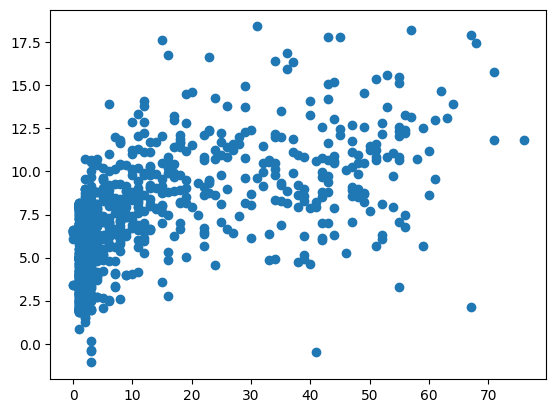

In [11]:
plt.scatter(params_table['matches_played'], params_table['ret'])

In [12]:
model._grad_log

# print average gradient update over all entries for each parameter (4 total) after training
grad_log_i = torch.stack([g['grad_i'] for g in model._grad_log])
grad_log_j = torch.stack([g['grad_j'] for g in model._grad_log])
avg_gradients_i = torch.mean(grad_log_i, dim=0)
avg_gradients_j = torch.mean(grad_log_j, dim=0)
print(f"Average gradients for player i: {avg_gradients_i}")
print(f"Average gradients for player j: {avg_gradients_j}")

Average gradients for player i: tensor([-2.5594e-05, -3.4124e-04,  3.6750e-04,  4.7074e-05])
Average gradients for player j: tensor([ 4.6275e-04, -4.8688e-04, -2.9127e-04,  5.2485e-05])


In [13]:
total_pts_col = wta['serve_pts'] + wta['return_pts']

# average of each raw per-match ratio across every row in `wta`
wta_avg_raw = {
    'ace_rate':                  (wta['aces'] / wta['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'df_rate':                   (wta['dfs'] / wta['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'first_serve_in_rate':       (wta['first_in'] / wta['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'first_serve_pts_win_rate':  (wta['first_won'] / wta['first_in']).replace([np.inf, -np.inf], np.nan).mean(),
    'second_serve_pts_win_rate': (wta['second_won'] / wta['second_in']).replace([np.inf, -np.inf], np.nan).mean(),
    'break_pts_save_rate':       (wta['bp_saved'] / wta['bk_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'return_pts_win_rate':       (wta['return_pts_won'] / wta['return_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'winner_rate':               (wta['winners'] / total_pts_col).replace([np.inf, -np.inf], np.nan).mean(),
    'unforced_error_rate':       (wta['unforced'] / total_pts_col).replace([np.inf, -np.inf], np.nan).mean(),
}

# what each predictor in RatingModel returns when both players are uniform-rated at 5.0
uniform_model = RatingModel(2)
with torch.no_grad():
    uniform_model.params.fill_(5.0)

uniform_pred = {key: getattr(uniform_model, key)(0, 1).item() for key in RatingModel.PREDICTORS}


comparison = pd.DataFrame({
    'wta_average': wta_avg_raw,
    'model_prediction (rating=5.0)': uniform_pred,
}).reindex(RatingModel.PREDICTORS)
comparison['diff (wta - rating=5.0)'] = comparison['wta_average'] - comparison['model_prediction (rating=5.0)']

display(comparison)


,wta_average,model_prediction (rating=5.0),diff (wta - rating=5.0)
first_serve_pts_win_rate,0.618012,0.6800,-0.061988
second_serve_pts_win_rate,0.443155,0.4800,-0.036845
break_pts_save_rate,0.513649,0.5854,-0.071751
first_serve_in_rate,0.658385,0.6350,0.023385
df_rate,0.051525,0.0450,0.006525
ace_rate,0.033295,0.0700,-0.036705
return_pts_win_rate,0.441899,0.3846,0.057299
winner_rate,0.144455,0.1650,-0.020545
unforced_error_rate,0.190019,0.1850,0.005019


# ATP Parameter Tuning

In [14]:
# Same pull as the WTA section -- filtering it costs no additional API calls.
atp = all_matches[all_matches['gender'] == 'men'].reset_index(drop=True)

print(f'ATP: {len(atp)} rows over {atp["match_id"].nunique()} matches')
display(coverage_report(atp))
atp.tail(10)

ATP: 7541 rows over 3789 matches


,present,missing,pct_present
serve_pts,7541,0,100.0
aces,7541,0,100.0
dfs,7541,0,100.0
first_in,7541,0,100.0
first_won,7541,0,100.0
second_in,7541,0,100.0
second_won,7541,0,100.0
bk_pts,7508,33,99.6
bp_saved,7508,33,99.6
return_pts,7541,0,100.0


,match_id,player,opponent,set,serve_pts,aces,dfs,first_in,first_won,second_in,second_won,bk_pts,bp_saved,return_pts,return_pts_won,winners,unforced,serve_gap,match_date,start_time,gender,competition,level,surface,round,player_id,opponent_id,won,winning_reason
7531,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Roman Safiullin,Hugo Grenier,Total,103.0,5.0,4.0,63.0,43.0,40.0,21.0,9.0,6.0,96.0,28.0,NaN,NaN,0.0,20260824,2026-08-24 22:05:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_64,sr:competitor:124930,sr:competitor:107357,False,None
7532,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Hugo Grenier,Roman Safiullin,Total,96.0,14.0,7.0,53.0,40.0,43.0,28.0,4.0,1.0,103.0,39.0,NaN,NaN,0.0,20260824,2026-08-24 22:05:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_64,sr:competitor:107357,sr:competitor:124930,True,None
7533,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Jenson Brooksby,Stefanos Tsitsipas,Total,75.0,2.0,0.0,58.0,39.0,17.0,10.0,6.0,4.0,97.0,36.0,NaN,NaN,0.0,20260824,2026-08-24 22:30:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_32,sr:competitor:195516,sr:competitor:122366,False,None
7534,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Stefanos Tsitsipas,Jenson Brooksby,Total,97.0,7.0,7.0,50.0,37.0,47.0,24.0,8.0,7.0,75.0,26.0,NaN,NaN,0.0,20260824,2026-08-24 22:30:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_32,sr:competitor:122366,sr:competitor:195516,True,None
7535,20260824-men-US_Open_Men_Singles-qualification...,Laslo Djere,Alexandre Muller,Total,63.0,6.0,8.0,39.0,24.0,24.0,8.0,9.0,4.0,61.0,20.0,NaN,NaN,0.0,20260824,2026-08-24 22:30:00+00:00,men,US Open Men Singles,grand_slam,None,qualification_round_1,sr:competitor:97231,sr:competitor:88992,False,None
7536,20260824-men-US_Open_Men_Singles-qualification...,Alexandre Muller,Laslo Djere,Total,61.0,3.0,4.0,34.0,26.0,27.0,15.0,6.0,5.0,63.0,31.0,NaN,NaN,0.0,20260824,2026-08-24 22:30:00+00:00,men,US Open Men Singles,grand_slam,None,qualification_round_1,sr:competitor:88992,sr:competitor:97231,True,None
7537,20260824-men-US_Open_Men_Singles-qualification...,Jack Pinnington Jones,Trevor Svajda,Total,76.0,8.0,6.0,38.0,30.0,38.0,16.0,6.0,3.0,71.0,33.0,NaN,NaN,0.0,20260824,2026-08-24 23:15:00+00:00,men,US Open Men Singles,grand_slam,None,qualification_round_1,sr:competitor:603104,sr:competitor:904525,True,None
7538,20260824-men-US_Open_Men_Singles-qualification...,Trevor Svajda,Jack Pinnington Jones,Total,71.0,4.0,3.0,38.0,25.0,33.0,13.0,11.0,7.0,76.0,30.0,NaN,NaN,0.0,20260824,2026-08-24 23:15:00+00:00,men,US Open Men Singles,grand_slam,None,qualification_round_1,sr:competitor:904525,sr:competitor:603104,False,None
7539,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Felix Balshaw,Aleksandar Kovacevic,Total,59.0,4.0,2.0,34.0,28.0,25.0,16.0,1.0,0.0,62.0,13.0,NaN,NaN,0.0,20260824,2026-08-24 23:30:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_64,sr:competitor:1067542,sr:competitor:188321,False,None
7540,20260824-men-ATP_Winston_Salem__USA_Men_Single...,Aleksandar Kovacevic,Felix Balshaw,Total,62.0,9.0,3.0,35.0,31.0,28.0,18.0,0.0,0.0,59.0,15.0,NaN,NaN,1.0,20260824,2026-08-24 23:30:00+00:00,men,"ATP Winston Salem, USA Men Singles",atp_250,None,round_of_64,sr:competitor:188321,sr:competitor:1067542,True,None


In [15]:
import torch
from train_player_params import RatingModel

# Every match contributes two rows, one per player, each naming its opponent
# outright -- so assigning indices is a straight read of two columns.
atp_name_to_index = {}
atp_matches_played = defaultdict(int)
for _, row in atp.iterrows():
    atp_matches_played[row['player']] += 1
    for name in (row['player'], row['opponent']):
        if name not in atp_name_to_index:
            atp_name_to_index[name] = len(atp_name_to_index)

print(f'{len(atp_name_to_index)} unique players')

493 unique players


In [16]:
from train_player_params import RatingModel
import torch

model = RatingModel(len(atp_name_to_index))
learning_rate = 5e-2

# betas[0] = 0.0 disables Adam's first-moment momentum.
#
# `model.params` is one tensor covering every player, so optimizer.step() writes
# to all of it on every call -- and a player who is not in the current matchup
# has gradient 0 but still carries stored momentum from their own last match.
# With the default 0.9 that momentum keeps pushing them for ~100 further steps,
# overshooting their real update by about 5x in the same direction. Across
# 18,892 sequential single-match updates that makes each rating a 5x-amplified
# echo of the player's most recent match rather than their season.
#
# At 0.0 the first moment is just the current gradient, so zero gradient means
# zero movement, while betas[1] keeps Adam's per-parameter step scaling.
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.0, 0.999))


In [17]:
def rate(numerator, denominator):
    """Serve-stat ratio, or None when the denominator is 0 / NaN (e.g. bk_pts
    is 0 when no break points were faced, and shot-level stats are only
    collected at events with enhanced coverage) so that one target can be
    dropped."""
    if not denominator or pd.isna(denominator) or pd.isna(numerator):
        return None
    return numerator / denominator

for _, row in atp.iterrows():
    i = atp_name_to_index[row['player']]     # the player whose serve stats these are
    j = atp_name_to_index[row['opponent']]

    total_pts = row['serve_pts'] + row['return_pts']

    raw = {
        'ace_rate':                  rate(row['aces'],           row['serve_pts']),
        'df_rate':                   rate(row['dfs'],            row['serve_pts']),
        'first_serve_in_rate':       rate(row['first_in'],       row['serve_pts']),
        'first_serve_pts_win_rate':  rate(row['first_won'],      row['first_in']),
        'second_serve_pts_win_rate': rate(row['second_won'],     row['second_in']),
        'break_pts_save_rate':       rate(row['bp_saved'],       row['bk_pts']),
        'return_pts_win_rate':       rate(row['return_pts_won'], row['return_pts']),
        'winner_rate':               rate(row['winners'],        total_pts),
        'unforced_error_rate':       rate(row['unforced'],       total_pts),
    }
    # Drop only the undefined target(s) via weight 0 -- keep the rest of the row.
    # e.g. bk_pts == 0 simply removes the break-point predictor for this update.
    user_set_weights = {
        'ace_rate':                  0.5,
        'df_rate':                   1,
        'first_serve_in_rate':       1,
        'first_serve_pts_win_rate':  0.5,
        'second_serve_pts_win_rate': 1,
        'break_pts_save_rate':       0.5,
        'return_pts_win_rate':       1,
        'winner_rate':               1,
        'unforced_error_rate':       1,
    }
    weights = {k: (0.0 if v is None else user_set_weights[k]) for k, v in raw.items()}
    targets = {k: (0.0 if v is None else v) for k, v in raw.items()}

    model.update(i, j, targets, optimizer, weights)  # defaults to 1 step

In [23]:
# print maximum and minimum values of each parameter (4 total) after training
for param_unit in model.params.T:
    # print(param_unit)
    param_values = param_unit.detach().numpy()
    print(f"Max values: {param_values.max(axis=0)}")
    print(f"Min values: {param_values.min(axis=0)}")
    print(f"Mean values: {param_values.mean(axis=0)}")
    print()

Max values: 10.295931816101074
Min values: -2.237596035003662
Mean values: 4.898843765258789

Max values: 9.932466506958008
Min values: -2.545893669128418
Mean values: 3.711632490158081

Max values: 11.15174674987793
Min values: -0.423281192779541
Mean values: 4.808289527893066

Max values: 12.621386528015137
Min values: -0.9818177223205566
Mean values: 5.748358726501465



In [19]:
# full table of every player's learned parameters (columns are, in order,
# the srv / ret / shot / cons attributes = param indices 0, 1, 2, 3)
index_to_name = {idx: name for name, idx in atp_name_to_index.items()}
params_table = pd.DataFrame(
    model.params.detach().numpy(),
    columns=['srv', 'ret', 'shot', 'cons'],
)
params_table.insert(0, 'player name', [index_to_name[i] for i in range(len(index_to_name))])
params_table['sum_ratings'] = params_table[['srv', 'ret', 'shot', 'cons']].sum(axis=1)
params_table['matches_played'] = [atp_matches_played[index_to_name[i]] for i in range(len(index_to_name))]
params_table = params_table.sort_values(by='sum_ratings', ascending=False).reset_index(drop=True)

with pd.option_context('display.max_rows', None):
    display(params_table)

,player name,srv,ret,shot,cons,sum_ratings,matches_played
0,Jannik Sinner,8.626640,4.043738,11.151747,12.406687,36.228813,75
1,Arthur Fils,8.441912,5.339954,10.575247,10.605955,34.963066,42
2,Alejandro Davidovich Fokina,9.223793,6.251470,8.182951,10.099218,33.757431,54
3,Joao Fonseca,7.129212,7.283132,9.060264,10.177911,33.650517,43
4,Brandon Nakashima,7.358249,5.273023,8.216333,12.620201,33.467804,62
5,Carlos Alcaraz,6.830767,9.932467,9.322801,6.890066,32.976097,42
6,Taylor Fritz,8.631693,1.926461,9.749359,12.621387,32.928902,59
7,Ben Shelton,9.088518,1.645768,10.833838,10.949681,32.517803,58
8,Lorenzo Musetti,5.697078,7.164442,10.270815,8.112994,31.245331,57
9,Daniel Merida,6.899919,9.021053,6.593553,8.310164,30.824692,43


In [20]:
total_pts_col = atp['serve_pts'] + atp['return_pts']

# average of each raw per-match ratio across every row in `atp`
atp_avg_raw = {
    'ace_rate':                  (atp['aces'] / atp['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'df_rate':                   (atp['dfs'] / atp['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'first_serve_in_rate':       (atp['first_in'] / atp['serve_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'first_serve_pts_win_rate':  (atp['first_won'] / atp['first_in']).replace([np.inf, -np.inf], np.nan).mean(),
    'second_serve_pts_win_rate': (atp['second_won'] / atp['second_in']).replace([np.inf, -np.inf], np.nan).mean(),
    'break_pts_save_rate':       (atp['bp_saved'] / atp['bk_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'return_pts_win_rate':       (atp['return_pts_won'] / atp['return_pts']).replace([np.inf, -np.inf], np.nan).mean(),
    'winner_rate':               (atp['winners'] / total_pts_col).replace([np.inf, -np.inf], np.nan).mean(),
    'unforced_error_rate':       (atp['unforced'] / total_pts_col).replace([np.inf, -np.inf], np.nan).mean(),
}

# what each predictor in RatingModel returns when both players are uniform-rated at 5.0
uniform_model = RatingModel(2)
with torch.no_grad():
    uniform_model.params.fill_(5.0)

uniform_pred = {key: getattr(uniform_model, key)(0, 1).item() for key in RatingModel.PREDICTORS}

# what each predictor returns when both players are rated (srv, ret, shot, cons) = (1.0, 9.4, 1.8, 9.1)
# custom_ratings = torch.tensor([-1.0, 11.8, -1.4, 13.2])
# custom_model = RatingModel(2)
# with torch.no_grad():
#     custom_model.params[:] = custom_ratings

# custom_pred = {key: getattr(custom_model, key)(0, 1).item() for key in RatingModel.PREDICTORS}

comparison = pd.DataFrame({
    'atp_average': atp_avg_raw,
    'model_prediction (rating=5.0)': uniform_pred,
    # f'model_prediction {tuple(custom_ratings.tolist())}': custom_pred,
}).reindex(RatingModel.PREDICTORS)
comparison['diff (atp - rating=5.0)'] = comparison['atp_average'] - comparison['model_prediction (rating=5.0)']
# comparison['diff (atp - custom rating)'] = comparison['atp_average'] - comparison[f'model_prediction {tuple(custom_ratings.tolist())}']

display(comparison)


,atp_average,model_prediction (rating=5.0),diff (atp - rating=5.0)
first_serve_pts_win_rate,0.717001,0.6800,0.037001
second_serve_pts_win_rate,0.512767,0.4800,0.032767
break_pts_save_rate,0.606743,0.5854,0.021343
first_serve_in_rate,0.637408,0.6350,0.002408
df_rate,0.035288,0.0450,-0.009712
ace_rate,0.082426,0.0700,0.012426
return_pts_win_rate,0.356915,0.3846,-0.027685
winner_rate,0.159639,0.1650,-0.005361
unforced_error_rate,0.154772,0.1850,-0.030228


# Summary Statistics

In [21]:
# combine wta and atp data into a single DataFrame for further analysis
combined = pd.concat([wta, atp], ignore_index=True)

# new columns for first_serve_pts_win_rate, second_serve_pts_win_rate, break_pts_save_rate, return_pts_win_rate, winner_rate, unforced_error_rate
combined['first_serve_pts_win_rate'] = (combined['first_won'] / combined['first_in']).replace([np.inf, -np.inf], np.nan)
combined['second_serve_pts_win_rate'] = (combined['second_won'] / combined['second_in']).replace([np.inf, -np.inf], np.nan)
combined['break_pts_save_rate'] = (combined['bp_saved'] / combined['bk_pts']).replace([np.inf, -np.inf], np.nan)
combined['return_pts_win_rate'] = (combined['return_pts_won'] / combined['return_pts']).replace([np.inf, -np.inf], np.nan)
combined['winner_rate'] = (combined['winners'] / (combined['serve_pts'] + combined['return_pts'])).replace([np.inf, -np.inf], np.nan)
combined['unforced_error_rate'] = (combined['unforced'] / (combined['serve_pts'] + combined['return_pts'])).replace([np.inf, -np.inf], np.nan)
combined['log_ace_rate'] = np.log10((combined['aces'] / combined['serve_pts'] + 5e-2).replace([np.inf, -np.inf], np.nan))
combined['log_df_rate'] = np.log10((combined['dfs'] / combined['serve_pts'] + 5e-2).replace([np.inf, -np.inf], np.nan))

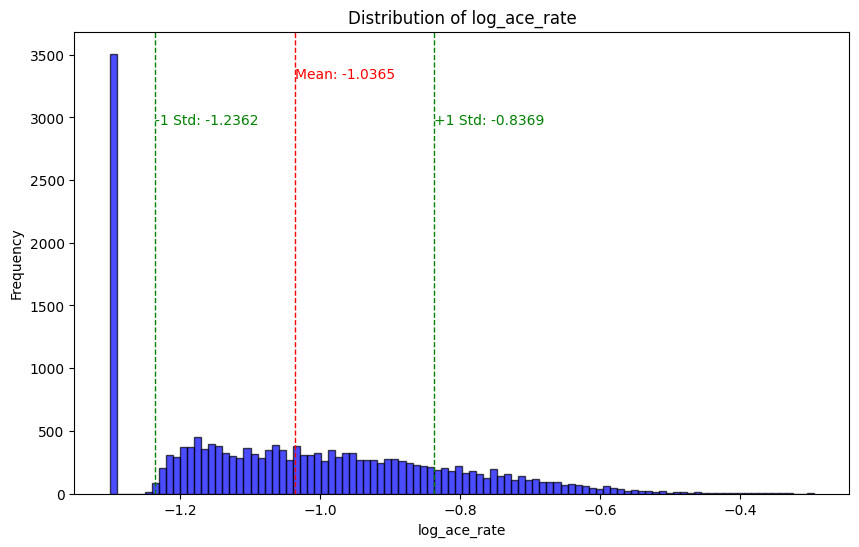

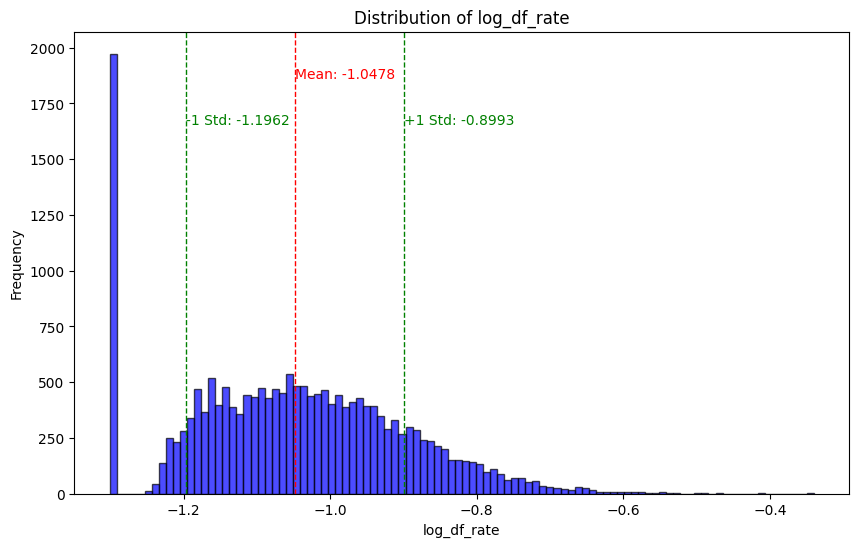

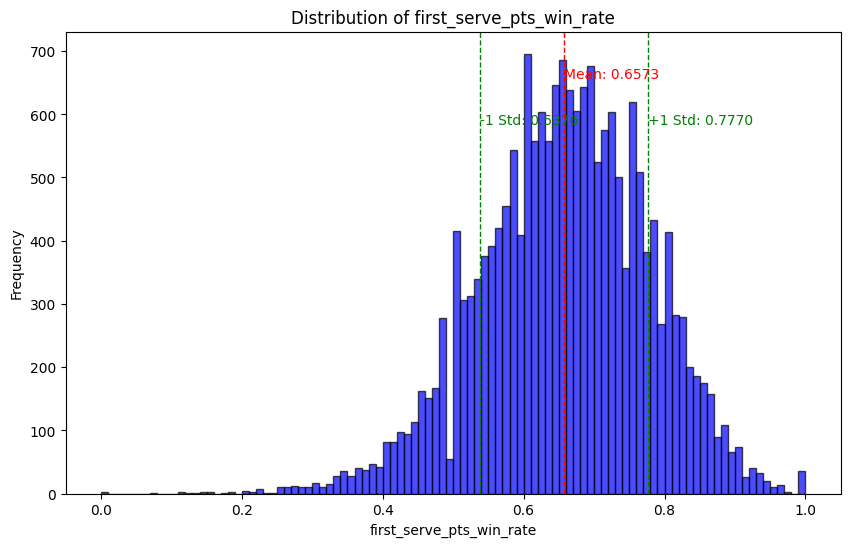

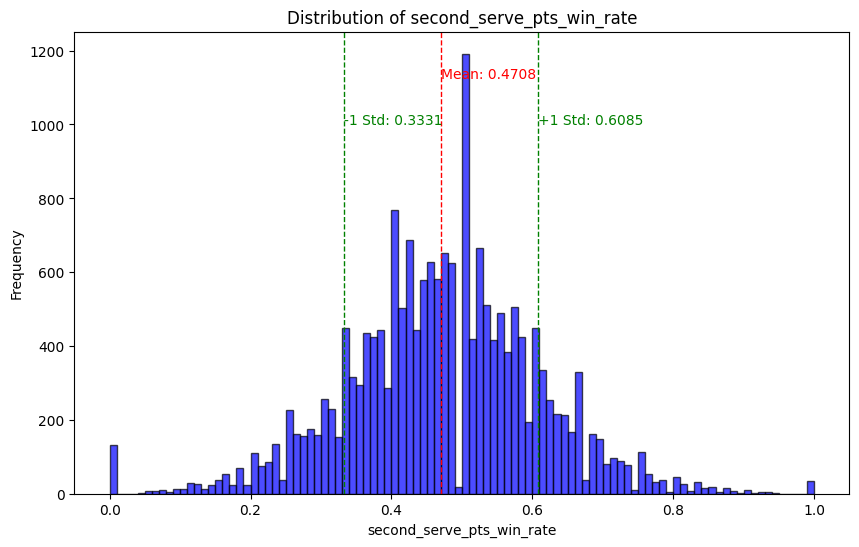

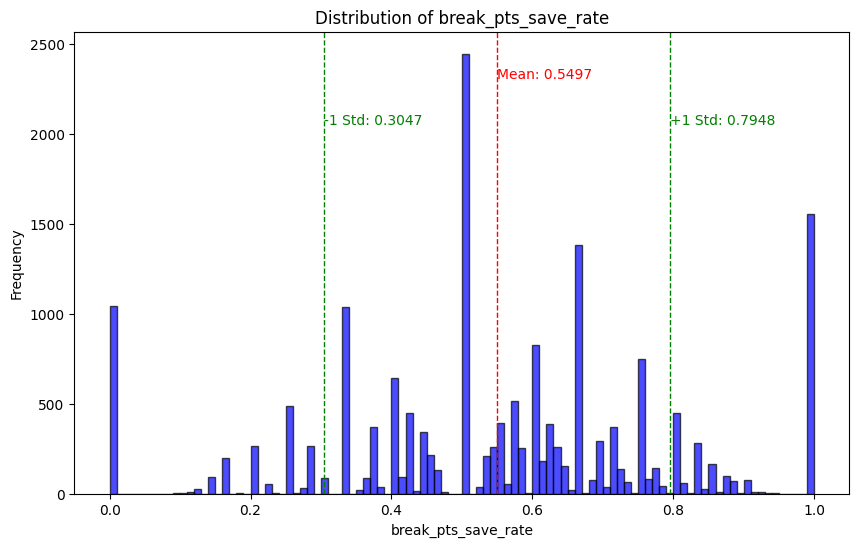

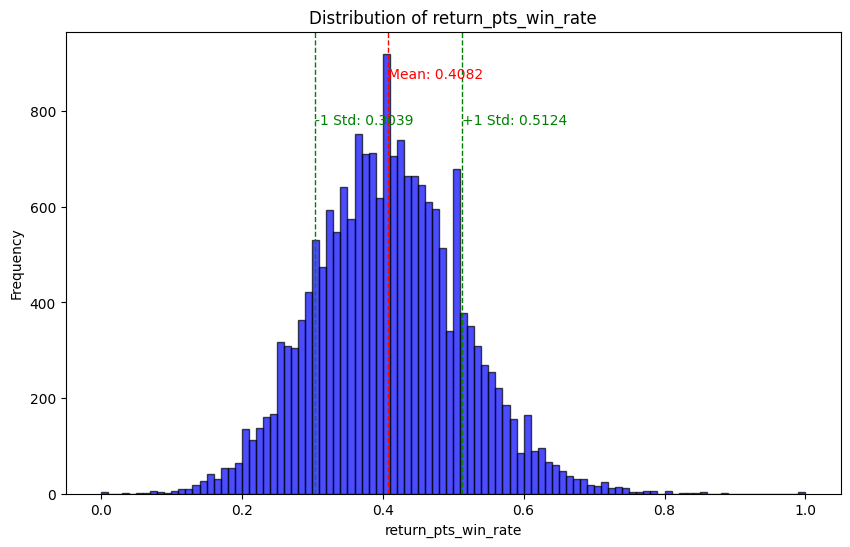

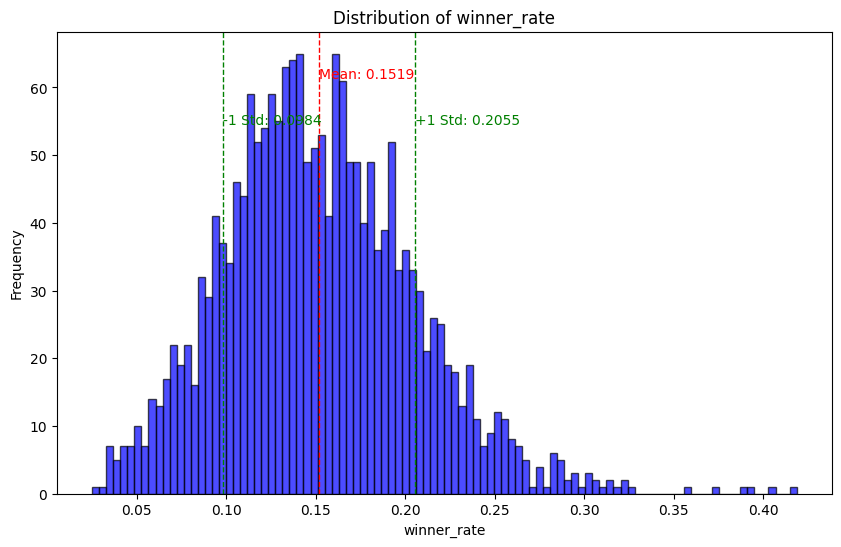

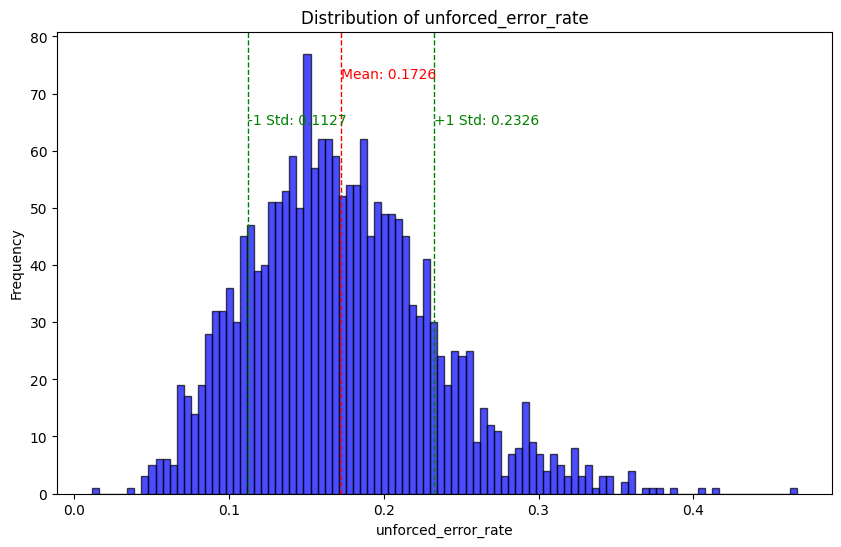

In [22]:
# graph the distribution of each rate, label the mean and standard deviation
from matplotlib import pyplot as plt

for rate in ['log_ace_rate', 'log_df_rate', 'first_serve_pts_win_rate', 'second_serve_pts_win_rate', 'break_pts_save_rate', 'return_pts_win_rate', 'winner_rate', 'unforced_error_rate']:
    plt.figure(figsize=(10, 6))
    plt.hist(combined[rate].dropna(), bins=100, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f'Distribution of {rate}')
    plt.xlabel(rate)
    plt.ylabel('Frequency')
    mean = combined[rate].mean()
    std = combined[rate].std()
    plt.axvline(mean, color='red', linestyle='dashed', linewidth=1)
    plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1)
    plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
    plt.text(mean, plt.ylim()[1]*0.9, f'Mean: {mean:.4f}', color='red')
    plt.text(mean + std, plt.ylim()[1]*0.8, f'+1 Std: {mean + std:.4f}', color='green')
    plt.text(mean - std, plt.ylim()[1]*0.8, f'-1 Std: {mean - std:.4f}', color='green')
    plt.show()
